In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/Superstore.csv", encoding="latin-1")
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")

ts = df.set_index("Order Date")["Sales"].resample("W").sum().sort_index()
print("Weeks:", len(ts), "| Range:", ts.index.min().date(), "→", ts.index.max().date())
ts.head()

Weeks: 209 | Range: 2014-01-05 → 2017-12-31


Order Date
2014-01-05     324.044
2014-01-12    4599.572
2014-01-19    4509.127
2014-01-26    3842.388
2014-02-02    1642.310
Freq: W-SUN, Name: Sales, dtype: float64

In [2]:
data = pd.DataFrame({"sales": ts})
data["year"] = data.index.year
data["month"] = data.index.month
data["weekofyear"] = data.index.isocalendar().week.astype("int")
data.head()

,sales,year,month,weekofyear
Order Date,,,,
2014-01-05,324.044,2014,1,1
2014-01-12,4599.572,2014,1,2
2014-01-19,4509.127,2014,1,3
2014-01-26,3842.388,2014,1,4
2014-02-02,1642.310,2014,2,5


In [3]:
for lag in [1, 2, 4, 52]:
    data[f"lag_{lag}"] = data["sales"].shift(lag)

data[["sales", "lag_1", "lag_2", "lag_4", "lag_52"]].head(8)

,sales,lag_1,lag_2,lag_4,lag_52
Order Date,,,,,
2014-01-05,324.044,NaN,NaN,NaN,NaN
2014-01-12,4599.572,324.044,NaN,NaN,NaN
2014-01-19,4509.127,4599.572,324.044,NaN,NaN
2014-01-26,3842.388,4509.127,4599.572,NaN,NaN
2014-02-02,1642.310,3842.388,4509.127,324.044,NaN
2014-02-09,756.888,1642.310,3842.388,4599.572,NaN
2014-02-16,2780.094,756.888,1642.310,4509.127,NaN
2014-02-23,227.236,2780.094,756.888,3842.388,NaN


In [4]:
data["roll_mean_4"]  = data["sales"].shift(1).rolling(4).mean()
data["roll_mean_12"] = data["sales"].shift(1).rolling(12).mean()
data.tail()

,sales,year,month,weekofyear,lag_1,lag_2,lag_4,lag_52,roll_mean_4,roll_mean_12
Order Date,,,,,,,,,,
2017-12-03,32354.5700,2017,12,48,20087.249,35344.423,31325.571,22963.279,26832.27875,21350.876600
2017-12-10,24006.9580,2017,12,49,32354.570,20087.249,20571.872,25271.818,27089.52850,22498.520350
2017-12-17,10495.9630,2017,12,50,24006.958,32354.570,35344.423,26505.970,27948.30000,22536.373100
2017-12-24,23662.3640,2017,12,51,10495.963,24006.958,20087.249,21384.952,21736.18500,21113.064267
2017-12-31,8977.8318,2017,12,52,23662.364,10495.963,32354.570,7053.958,22629.96375,22341.480767


In [5]:
data = data.dropna()
print("Usable rows after feature engineering:", len(data))

Usable rows after feature engineering: 157


In [6]:
test_size = 26  # hold out the most recent ~6 months
train = data.iloc[:-test_size]
test  = data.iloc[-test_size:]

print("Train:", train.index.min().date(), "→", train.index.max().date(), f"({len(train)} wks)")
print("Test :", test.index.min().date(), "→", test.index.max().date(), f"({len(test)} wks)")

Train: 2015-01-04 → 2017-07-02 (131 wks)
Test : 2017-07-09 → 2017-12-31 (26 wks)


In [7]:
feature_cols = [c for c in data.columns if c != "sales"]

X_train, y_train = train[feature_cols], train["sales"]
X_test,  y_test  = test[feature_cols],  test["sales"]

print("Features:", feature_cols)
data.to_csv("../data/prepared_weekly.csv")

Features: ['year', 'month', 'weekofyear', 'lag_1', 'lag_2', 'lag_4', 'lag_52', 'roll_mean_4', 'roll_mean_12']


In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(name, y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"{name:16s} MAE: {mae:8,.0f} | RMSE: {rmse:8,.0f} | MAPE: {mape:5.1f}%")
    return {"model": name, "MAE": mae, "RMSE": rmse, "MAPE": mape}

# Baseline: "same week last year" (seasonal naive)
results = []
results.append(evaluate("Seasonal naive", y_test, X_test["lag_52"]))

Seasonal naive   MAE:    7,706 | RMSE:    9,721 | MAPE:  45.0%


In [9]:
from prophet import Prophet

prophet_train = pd.DataFrame({"ds": train.index, "y": train["sales"].values})

m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m.fit(prophet_train)

future = pd.DataFrame({"ds": test.index})
pred_prophet = m.predict(future)["yhat"].values
results.append(evaluate("Prophet", y_test, pred_prophet))

19:28:31 - cmdstanpy - INFO - Chain [1] start processing
19:28:31 - cmdstanpy - INFO - Chain [1] done processing


Prophet          MAE:    5,818 | RMSE:    7,617 | MAPE:  36.8%


In [10]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=300, learning_rate=0.05,
                   max_depth=4, random_state=42)
xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)
results.append(evaluate("XGBoost", y_test, pred_xgb))

XGBoost          MAE:    6,446 | RMSE:    7,926 | MAPE:  41.6%


In [11]:
results_df = pd.DataFrame(results).set_index("model")
results_df.sort_values("MAPE")

,MAE,RMSE,MAPE
model,,,
Prophet,5818.436776,7617.163715,36.756960
XGBoost,6445.882025,7926.236369,41.645280
Seasonal naive,7705.847569,9721.114636,45.022797


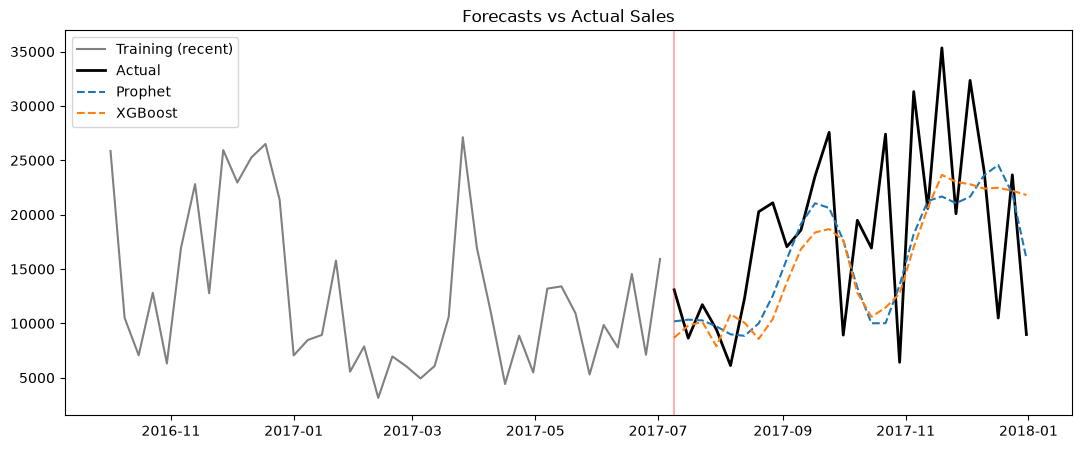

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(13,5))
plt.plot(train.index[-40:], y_train[-40:], label="Training (recent)", color="gray")
plt.plot(test.index, y_test, label="Actual", color="black", linewidth=2)
plt.plot(test.index, pred_prophet, label="Prophet", linestyle="--")
plt.plot(test.index, pred_xgb, label="XGBoost", linestyle="--")
plt.axvline(test.index[0], color="red", alpha=0.3)  # train/test boundary
plt.legend(); plt.title("Forecasts vs Actual Sales")
plt.show()

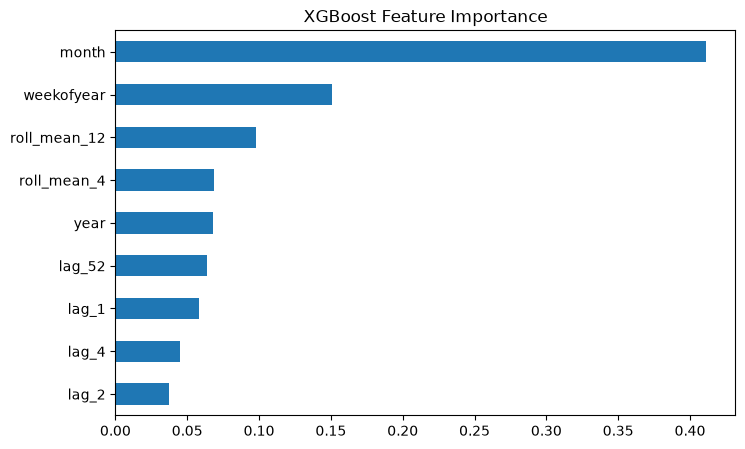

In [13]:
importance = pd.Series(xgb.feature_importances_, index=feature_cols).sort_values()
importance.plot(kind="barh", figsize=(8,5), title="XGBoost Feature Importance")
plt.show()

In [14]:
import joblib

xgb.fit(data[feature_cols], data["sales"])   # refit on ALL data before saving
joblib.dump(xgb, "../models/xgb_model.pkl")
joblib.dump(feature_cols, "../models/feature_cols.pkl")
results_df.to_csv("../models/model_results.csv")
print("Saved!")

Saved!
